## Visualize footprint for the DR1 catalog

* Uses the random catalog for DR1 and BGS catalogs and plots a mollview plot

In [1]:
## Folders repo_dir(), data_dir(), plot_dir()
import sys
sys.path.insert(0, '/global/homes/z/zzhang13/DESI/')
from setup import *

In [40]:
plotdir = '/global/homes/z/zzhang13/DESI/plots/'

In [ ]:
from scipy.stats import kde
import h5py
import astropy.io.fits as fits
import csv
import pandas as pd
import numpy as np
import healpy as hp
import tables
import pickle
import os
from astropy.table import Table
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from astropy.io import ascii
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import incredible as cr
from scipy.special import erf
from scipy import stats
import scipy.optimize as opt
from scipy import stats
import scipy.optimize as opt
import emcee
import tqdm
import pickle
import glob
from astropy import table
from astropy.table import Table, join, unique
from specutils import SpectralRegion
from scipy.interpolate import BSpline, make_interp_spline, UnivariateSpline

from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
import numpy as np
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
cosmo = Planck18

## Functions for computing spectroscopic richness and profiles
from tools.projection_functions import *


##Plotting
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from astropy.io import ascii
from astropy.io import fits

plot_params = {

'axes.linewidth': 1.25,
'xtick.major.width': 1, 'ytick.major.width': 1,
'xtick.minor.width': 1, 'ytick.minor.width': 1,
'xtick.major.size': 12, 'ytick.major.size': 12,
'xtick.labelsize': 12, 'ytick.labelsize': 12,
'xtick.direction': 'in', 'ytick.direction': 'in',
'xtick.major.pad': 6, 'xtick.minor.pad': 6,
'figure.constrained_layout.use': True,
#'text.usetex': True,
'font.family': 'Serif',
'font.size': 14,
'legend.fontsize': 11
    
}
plt.rcParams.update(plot_params)

## Functions 

In [ ]:
import numpy as np
import healpy as hp
from astropy.table import Table
from astropy.cosmology import Planck18
import astropy.units as u


# ============================================================
# 1. Geometry / cosmology helpers
# ============================================================

def radec_to_unitvec(ra_deg, dec_deg):
    """
    Convert RA, Dec in degrees to 3D unit vectors.
    Returns array of shape (N, 3).
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    cosd = np.cos(dec)
    x = cosd * np.cos(ra)
    y = cosd * np.sin(ra)
    z = np.sin(dec)
    return np.column_stack((x, y, z))


def annulus_theta_radians(z, Rmin_hMpc=1.5, Rmax_hMpc=10.0, cosmo=Planck18):
    """
    Convert projected comoving annulus radii [Mpc/h] to angular radii [radians]
    using comoving transverse distance.
    """
    h = cosmo.h

    Rmin_Mpc = (Rmin_hMpc / h) * u.Mpc
    Rmax_Mpc = (Rmax_hMpc / h) * u.Mpc

    Dm = cosmo.comoving_transverse_distance(z)  # Mpc

    th_min = (Rmin_Mpc / Dm).decompose().value
    th_max = (Rmax_Mpc / Dm).decompose().value
    return th_min, th_max


# ============================================================
# 2. Build galaxy HEALPix index
# ============================================================

def build_galaxy_healpix_index(ra_gal, dec_gal, nside=4096, nest=False):
    """
    Build a fast lookup structure from galaxy positions.

    Returns a dict containing:
      - order: galaxy indices sorted by pixel
      - pix: pixel value assigned to each galaxy
      - uniq_pix: unique pixel ids
      - count: builds counts per pixel from 0 to max pixel value
      - start: start index in 'order' for each unique pixel
      - end: end index in 'order' for each unique pixel
      - nside, nest
    """
    theta = np.deg2rad(90.0 - dec_gal)  # colatitude
    phi = np.deg2rad(ra_gal)
    npix = hp.nside2npix(nside)
    pix = hp.ang2pix(nside, theta, phi, nest=nest)
    
    
    order = np.argsort(pix)
    pix_sorted = pix[order]

    uniq_pix, start = np.unique(pix_sorted, return_index=True)
    end = np.r_[start[1:], len(pix_sorted)]

    
    count_map = np.bincount(pix, minlength=npix)

    return {
        "nside": nside,
        "nest": nest,
        "order": order,
        "pix": pix,
        "uniq_pix": uniq_pix,
        "count": count_map,
        "start": start,
        "end": end,
    }

def gather_candidates(index, pix_list):
    """
    Given a list of HEALPix pixels, return original galaxy indices in those pixels.
    """
    uniq_pix = index["uniq_pix"]
    start = index["start"]
    end = index["end"]
    order = index["order"]
    
    pix_list = np.asarray(pix_list, dtype=uniq_pix.dtype)

    pos = np.searchsorted(uniq_pix, pix_list)
    
    inside = pos < len(uniq_pix)
    pos_valid = pos[inside]
    pix_valid = pix_list[inside]
    
    good = uniq_pix[pos_valid] == pix_valid
    pos = pos_valid[good]

    if len(pos) == 0:
        return np.empty(0, dtype=np.int64)

    if len(pos) == 1:
        p = pos[0]
        return order[start[p]:end[p]]

    chunks = [order[start[p]:end[p]] for p in pos]
    return np.concatenate(chunks)


## Main Counting Function
def count_galaxies_in_annuli(
    cluster_ids,
    ra_cl,
    dec_cl,
    z_cl,
    ra_gal,
    dec_gal,
    nside=4096,
    Rmin_hMpc=1.5,
    Rmax_hMpc=10.0,
    cosmo=Planck18,
    nest=False,
    verbose_every=100,
):
    """
    For each cluster, count number of galaxies in projected annulus [Rmin, Rmax].

    Inputs
    ------
    cluster_ids : array-like
    ra_cl, dec_cl, z_cl : cluster arrays
    ra_gal, dec_gal : galaxy arrays
    nside : HEALPix resolution

    Returns
    -------
    astropy.table.Table with columns:
      cluster_id, ngal_2d
    """

    # ---- cast to numpy arrays
    cluster_ids = np.asarray(cluster_ids)
    ra_cl = np.asarray(ra_cl, dtype=np.float64)
    dec_cl = np.asarray(dec_cl, dtype=np.float64)
    z_cl = np.asarray(z_cl, dtype=np.float64)

    ra_gal = np.asarray(ra_gal, dtype=np.float64)
    dec_gal = np.asarray(dec_gal, dtype=np.float64)

    # ---- build galaxy spatial index once
    print("Building HEALPix index for galaxies...")
    hp_index = build_galaxy_healpix_index(ra_gal, dec_gal, nside=nside, nest=nest)

    # ---- precompute galaxy unit vectors once
    print("Precomputing galaxy unit vectors...")
    gal_vec = radec_to_unitvec(ra_gal, dec_gal)

    # ---- output counts
    ngal = np.zeros(len(cluster_ids), dtype=np.int32)

    print("Looping over clusters...")
    for i in range(len(cluster_ids)):
        if verbose_every is not None and (i % verbose_every == 0):
            print(f"  cluster {i}/{len(cluster_ids)}")

        # cluster center vector
        vec_c = radec_to_unitvec([ra_cl[i]], [dec_cl[i]])[0]

        # annulus angular radii
        th_min, th_max = annulus_theta_radians(
            z_cl[i],
            Rmin_hMpc=Rmin_hMpc,
            Rmax_hMpc=Rmax_hMpc,
            cosmo=cosmo
        )

        # HEALPix pixels overlapping outer disc
        pix_outer = hp.query_disc(
            nside=hp_index["nside"],
            vec=vec_c,
            radius=th_max,
            inclusive=True,
            nest=hp_index["nest"]
        )

        # galaxies in those pixels
        cand = gather_candidates(hp_index, pix_outer)
        if cand.size == 0:
            ngal[i] = 0
            continue

        # exact angular separation via dot products
        cosang = gal_vec[cand] @ vec_c
        np.clip(cosang, -1.0, 1.0, out=cosang)
        ang = np.arccos(cosang)

        ngal[i] = np.count_nonzero((ang >= th_min) & (ang < th_max))

    return Table({
        "cluster_id": cluster_ids,
        "ngal_2d": ngal
    })

# --------------------------------------------------
# smoothing helper
# --------------------------------------------------
def make_smooth_healpix_map(ra_deg, dec_deg, nside=128, sigma_deg=0.5):
    m = np.isfinite(ra_deg) & np.isfinite(dec_deg)
    ra_deg = np.asarray(ra_deg[m])
    dec_deg = np.asarray(dec_deg[m])

    theta = np.radians(90.0 - dec_deg)
    phi = np.radians(ra_deg)

    pix = hp.ang2pix(nside, theta, phi)
    counts = np.bincount(pix, minlength=hp.nside2npix(nside)).astype(float)

    original_empty = (counts == 0)
    sigma_rad = np.radians(sigma_deg)
    smooth_map = hp.smoothing(counts, sigma=sigma_rad, verbose=False)
    smooth_map[original_empty] = hp.UNSEEN
    return smooth_map

#----------------
# Convert ra,dec to x,y in mollview
#-------------------
def radec_to_moll_xy(ra_deg, dec_deg):
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)

    # shift RA into [-180, 180] and flip so RA increases to the left
    lon = (ra_deg + 180.0) % 360.0 - 180.0
    lon = -lon

    lon = np.radians(lon)
    lat = np.radians(dec_deg)

    # solve for auxiliary angle theta
    theta = lat.copy()
    for _ in range(10):
        theta -= (2*theta + np.sin(2*theta) - np.pi*np.sin(lat)) / (2 + 2*np.cos(2*theta))

    x = 2*np.sqrt(2)/np.pi * lon * np.cos(theta)
    y = np.sqrt(2) * np.sin(theta)
    return x, y

## Import catalogs

### redMaPPer galaxies

In [ ]:
## Find overlap region between RM and and galaxies. To do later. 
with open(data_dir() + 'bgs_clus_RM_gal_matched.pickle', 'rb') as handle:
    bgs_matched = pickle.load(handle)

rm_tab = unique(bgs_matched, keys='ID') #Filter by RM ID

In [ ]:
#Build cluster coordinates
ra_cl = np.asarray(rm_tab['RA_x'])
dec_cl = np.asarray(rm_tab['DEC_x'])
z_cl = np.asarray(rm_tab['Z_SPEC_x'])
vecs = radec_to_unitvec(ra_cl, dec_cl)

### DR9 Random Catalog

In [6]:


# directory containing randoms-*-*.fits
dr9_random_dir = '/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/'

# find matching files
files = sorted(glob.glob(f"{dr9_random_dir}/randoms-10-0.fits")) #Sample one file first
print(f"Found {len(files)} files")

if len(files) == 0:
    raise FileNotFoundError("No files matched randoms-*.fits")

ra_list = []
dec_list = []

for fn in files:
    with fits.open(fn, memmap=True) as hdul:
        data = hdul[1].data   # assumes catalog table in extension 1
        ra = np.asarray(data["RA"], dtype=float)
        dec = np.asarray(data["DEC"], dtype=float)

        m = np.isfinite(ra) & np.isfinite(dec)
        ra_list.append(ra[m])
        dec_list.append(dec[m])

        hdul.close()

rand_ra = np.concatenate(ra_list)
rand_dec = np.concatenate(dec_list)

### BGS footprint

In [10]:
## Test using one random catalog
numRand = 0
desiDir = '/global/cfs/cdirs/desi/survey/catalogs/dr1/LSS/iron/LSScats/v1.5pip/'
randomCat = "BGS_ANY_{}_full_HPmapcut.ran.fits".format(numRand)
print(randomCat)
BGS_rand_data = Table.read(desiDir + randomCat)[::100]

BGS_ANY_0_full_HPmapcut.ran.fits


In [11]:
# Build coordinate vector with random catalog
BGS_rand_ra = np.asarray(BGS_rand_data['RA'])
BGS_rand_dec = np.asarray(BGS_rand_data['DEC'])
BGS_rand_vecs = radec_to_unitvec(BGS_rand_ra, BGS_rand_dec)

#survey_area_deg2 = 7473 #From DESI DR1   # example, replace with real value
#survey_area_sr = survey_area_deg2 * (np.pi / 180.0)**2
#nrand_bar = len(rand_ra) / survey_area_sr   # randoms per sr

## Plotting mollview

### Helper functions

In [12]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap

# --------------------------------------------------
# smoothing helper
# --------------------------------------------------
def make_smooth_healpix_map(ra_deg, dec_deg, nside=128, sigma_deg=0.5):
    m = np.isfinite(ra_deg) & np.isfinite(dec_deg)
    ra_deg = np.asarray(ra_deg[m])
    dec_deg = np.asarray(dec_deg[m])

    theta = np.radians(90.0 - dec_deg)
    phi = np.radians(ra_deg)

    pix = hp.ang2pix(nside, theta, phi)
    counts = np.bincount(pix, minlength=hp.nside2npix(nside)).astype(float)

    original_empty = (counts == 0)
    sigma_rad = np.radians(sigma_deg)
    smooth_map = hp.smoothing(counts, sigma=sigma_rad, verbose=False)
    smooth_map[original_empty] = hp.UNSEEN
    return smooth_map

#----------------
# Convert ra,dec to x,y in mollview
#-------------------
def radec_to_moll_xy(ra_deg, dec_deg):
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)

    # shift RA into [-180, 180] and flip so RA increases to the left
    lon = (ra_deg + 180.0) % 360.0 - 180.0
    lon = -lon

    lon = np.radians(lon)
    lat = np.radians(dec_deg)

    # solve for auxiliary angle theta
    theta = lat.copy()
    for _ in range(10):
        theta -= (2*theta + np.sin(2*theta) - np.pi*np.sin(lat)) / (2 + 2*np.cos(2*theta))

    x = 2*np.sqrt(2)/np.pi * lon * np.cos(theta)
    y = np.sqrt(2) * np.sin(theta)
    return x, y

def make_binary_mask(hpmap):
    mask = (hpmap != hp.UNSEEN) & np.isfinite(hpmap) & (hpmap > 0)
    out = np.full_like(hpmap, hp.UNSEEN)
    out[mask] = 1.0
    return out



# ==================================================
# Helper functions
# ==================================================
def make_smooth_healpix_map(ra_deg, dec_deg, nside=128, sigma_deg=1.0):
    """
    Build a smoothed HEALPix count map from RA/Dec positions.
    Pixels that were originally empty are masked back to hp.UNSEEN
    after smoothing, so empty sky stays empty.
    """
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)

    m = np.isfinite(ra_deg) & np.isfinite(dec_deg)
    ra_deg = ra_deg[m]
    dec_deg = dec_deg[m]

    npix = hp.nside2npix(nside)

    theta = np.radians(90.0 - dec_deg)   # colatitude
    phi = np.radians(ra_deg)             # longitude

    pix = hp.ang2pix(nside, theta, phi)
    counts = np.bincount(pix, minlength=npix).astype(float)

    original_empty = (counts == 0)

    sigma_rad = np.radians(sigma_deg)
    smooth_map = hp.smoothing(counts, sigma=sigma_rad, verbose=False)

    # restore empty-sky mask
    smooth_map[original_empty] = hp.UNSEEN
    return smooth_map


def radec_to_moll_xy(ra_deg, dec_deg):
    """
    Convert RA/Dec in degrees to x,y coordinates on a Mollweide plane.
    Convention: RA increases to the left, matching standard sky maps.
    """
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)

    lon = (ra_deg + 180.0) % 360.0 - 180.0
    lon = -lon
    lon = np.radians(lon)
    lat = np.radians(dec_deg)

    # Newton solve for Mollweide auxiliary angle
    theta = lat.copy()
    for _ in range(12):
        denom = 2.0 + 2.0 * np.cos(2.0 * theta)
        step = (2.0 * theta + np.sin(2.0 * theta) - np.pi * np.sin(lat)) / denom
        theta -= step

    x = 2.0 * np.sqrt(2.0) / np.pi * lon * np.cos(theta)
    y = np.sqrt(2.0) * np.sin(theta)
    return x, y


def healpix_to_moll_image(hpmap, xsize=1600):
    """
    Project a 1D HEALPix map to a 2D Mollweide image array.
    """
    nside = hp.get_nside(hpmap)
    proj = hp.projector.MollweideProj(xsize=xsize)
    img = proj.projmap(
        hpmap,
        lambda x, y, z: hp.vec2pix(nside, x, y, z)
    )
    return np.ma.masked_invalid(img)


def positive_finite_values(arr):
    """
    Return positive finite unmasked values from an image/map array.
    """
    if np.ma.isMaskedArray(arr):
        vals = arr.compressed()
    else:
        vals = np.asarray(arr).ravel()
    vals = vals[np.isfinite(vals) & (vals > 0)]
    return vals


def draw_mollweide_boundary(ax, color='black', lw=1.0):
    """
    Draw the outer Mollweide ellipse boundary.
    """
    x = np.linspace(-2.0 * np.sqrt(2.0), 2.0 * np.sqrt(2.0), 1200)
    y = np.sqrt(2.0) * np.sqrt(np.clip(1.0 - (x / (2.0 * np.sqrt(2.0)))**2, 0, None))
    ax.plot(x,  y, color=color, lw=lw, zorder=10)
    ax.plot(x, -y, color=color, lw=lw, zorder=10)


def draw_graticule(ax, ra_lines=None, dec_lines=None, color='gray', lw=0.5, alpha=0.35):
    """
    Draw a simple RA/Dec graticule in Mollweide coordinates.
    """
    if ra_lines is None:
        ra_lines = [0, 60, 120, 180, 240, 300]
    if dec_lines is None:
        dec_lines = [-60, -30, 0, 30, 60]

    # Dec lines
    ra = np.linspace(0, 360, 1200)
    for dec in dec_lines:
        dec_arr = np.full_like(ra, dec, dtype=float)
        x, y = radec_to_moll_xy(ra, dec_arr)
        ax.plot(x, y, color=color, lw=lw, alpha=alpha, zorder=0)

    # RA lines
    dec = np.linspace(-89.9, 89.9, 900)
    for ra0 in ra_lines:
        ra_arr = np.full_like(dec, ra0, dtype=float)
        x, y = radec_to_moll_xy(ra_arr, dec)
        ax.plot(x, y, color=color, lw=lw, alpha=alpha, zorder=0)

In [38]:
def plot_randoms_and_clusters_mollweide(
    dr9_ra,
    dr9_dec,
    bgs_ra,
    bgs_dec,
    cluster_ra,
    cluster_dec,
    nside=128,
    sigma_deg=1.0,
    xsize=1600,
    dr9_cmap='viridis',
    bgs_cmap='plasma',
    bgs_alpha=0.35,
    cluster_color='red',
    cluster_size=8,
    title='DR9 randoms + BGS randoms + redMaPPer clusters'
):
    """
    Make a single clean Mollweide plot with:
      - DR9 smoothed map as background
      - BGS smoothed map as semi-transparent overlay
      - redMaPPer clusters as points
    """
    # ----------------------------------------------
    # Build smoothed HEALPix maps
    # ----------------------------------------------
    dr9_map = make_smooth_healpix_map(dr9_ra, dr9_dec, nside=nside, sigma_deg=sigma_deg)
    bgs_map = make_smooth_healpix_map(bgs_ra, bgs_dec, nside=nside, sigma_deg=sigma_deg)

    # ----------------------------------------------
    # Build binary mask
    # ----------------------------------------------
    #dr9_mask = make_binary_mask(dr9_map)
    #bgs_mask = make_binary_mask(bgs_map)
    dr9_mask =dr9_map
    bgs_mask = bgs_map

    # ----------------------------------------------
    # Project to 2D Mollweide images
    # ----------------------------------------------
    dr9_img = healpix_to_moll_image(dr9_mask, xsize=xsize)
    bgs_img = healpix_to_moll_image(bgs_mask , xsize=xsize)

    # ----------------------------------------------
    # Shared display scaling
    # ----------------------------------------------
    vals = np.concatenate([
        positive_finite_values(dr9_img),
        positive_finite_values(bgs_img)
    ])

    if len(vals) == 0:
        raise ValueError("No positive finite values found in projected maps.")

    vmin = np.percentile(vals, 5)
    vmax = np.percentile(vals, 99.5)

    # Safety for LogNorm
    vmin = max(vmin, 1e-6)
    vmax = max(vmax, vmin * 1.01)

    # ----------------------------------------------
    # Prepare figure/axis
    # ----------------------------------------------
    fig, ax = plt.subplots(figsize=(14, 7))
    extent = (-2.0 * np.sqrt(2.0), 2.0 * np.sqrt(2.0), -np.sqrt(2.0), np.sqrt(2.0))

    # Background DR9
    ax.imshow(
        dr9_img,
        origin='lower',
        extent=extent,
        cmap=dr9_cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        alpha=0.8,
        zorder=1
    )

    # BGS overlay
    ax.imshow(
        bgs_img,
        origin='lower',
        extent=extent,
        cmap=bgs_cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        alpha=bgs_alpha,
        zorder=2
    )

    # ----------------------------------------------
    # Overlay clusters
    # ----------------------------------------------
    cluster_ra = np.asarray(cluster_ra, dtype=float)
    cluster_dec = np.asarray(cluster_dec, dtype=float)
    mcl = np.isfinite(cluster_ra) & np.isfinite(cluster_dec)

    x_cl, y_cl = radec_to_moll_xy(cluster_ra[mcl], cluster_dec[mcl])
    ax.scatter(
        x_cl,
        y_cl,
        s=cluster_size,
        c=cluster_color,
        alpha=0.7,
        linewidths=0,
        zorder=3
    )

    # ----------------------------------------------
    # Decorations
    # ----------------------------------------------
    draw_graticule(ax)
    draw_mollweide_boundary(ax)

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=16)

    # Legend
    legend_handles = [
        Line2D([0], [0], color=plt.cm.get_cmap(dr9_cmap)(0.8), lw=6, label='DR9 randoms'),
        Line2D([0], [0], color=plt.cm.get_cmap(bgs_cmap)(0.8), lw=6, alpha=bgs_alpha, label='BGS randoms'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_color,
               markersize=7, linestyle='None', label='redMaPPer clusters')
    ]
    ax.legend(handles=legend_handles, loc='lower left', frameon=True)

    plt.tight_layout()
    return fig, ax


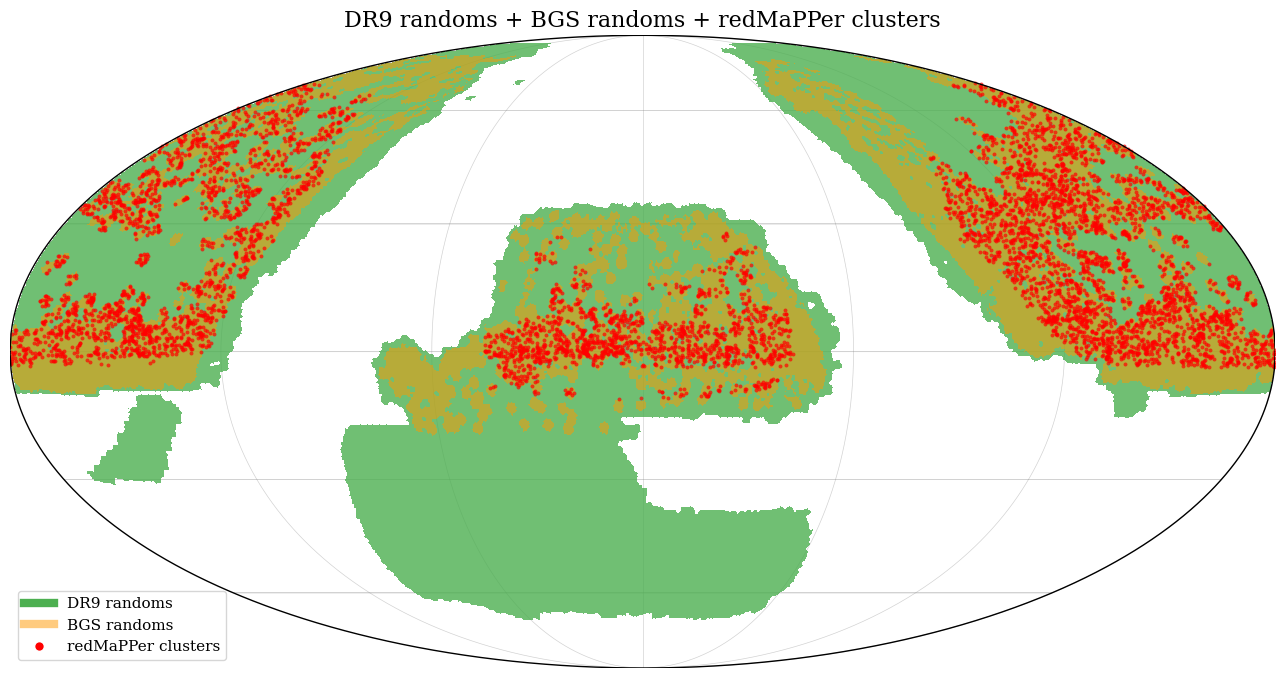

In [41]:

# ==================================================
# Example call
# Assumes these arrays already exist in memory:
#   rand_ra, rand_dec
#   BGS_rand_ra, BGS_rand_dec
#   ra_cl, dec_cl
# ==================================================

dr9_cmap = ListedColormap(["#4CAF50"])   # green
bgs_cmap = ListedColormap(["#FF9800"])   # orange

fig, ax = plot_randoms_and_clusters_mollweide(
    dr9_ra=rand_ra,
    dr9_dec=rand_dec,
    bgs_ra=BGS_rand_ra,
    bgs_dec=BGS_rand_dec,
    cluster_ra=ra_cl,
    cluster_dec=dec_cl,
    nside=128,
    sigma_deg=1.0,
    xsize=1600,
    bgs_alpha=0.5,
    dr9_cmap = dr9_cmap,
    bgs_cmap = bgs_cmap
)

plt.savefig(plotdir+'mollview_footprint.png')
plt.show()